# Phoneme Feature Analysis — `feats.py`

Exploration notebook for the three utilities in `feats.py`:

| Function | What it gives you |
|---|---|
| `phoneme_embeddings(lang_code)` | Articulatory feature vectors (21-dim SPE/IPA) per phoneme |
| `build_ngram_lm(words, lang_code, n)` | n-gram language model over IPA phone sequences |
| `perplexity(lm, test_words, lang_code, n)` | Phonotactic perplexity of a word list under the LM |

Covers:
- Phoneme vector space (UMAP / PCA), clustering, nearest-neighbour lookup
- LM training + perplexity on held-out words
- Cross-lingual perplexity: train on lang A, score words from lang B
- Per-grapheme ambiguity ranked by LM entropy

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
%pip install numpy==1.26.4           # array ops
%pip install scikit-learn==1.4.2     # PCA, KMeans, cosine similarity
%pip install umap-learn==0.5.6       # UMAP dimensionality reduction
%pip install matplotlib==3.8.4       # plotting
%pip install seaborn==0.13.2         # statistical plots
%pip install pandas==2.2.2           # tables
%pip install psutil==5.9.8           # memory monitoring
%pip install mlflow==2.12.2          # experiment tracking (optional)
# ipa-mappings — adjust path if needed
# %pip install ipa-mappings
# %pip install -e /path/to/ipa-mappings

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 52.3 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-1.26.4-cp314-cp314-linux_x86_64.whl size=7099920 sha256=8e864d0ef14b2b015df0524104ff68134129ef47b8980610e5fd39fc429d6e7f
  Stored in directory: /home/miro/.cache/pip/wheels/9f/41/2d/41d9edbbdf1331835527392f3da54c7de611dc6ba3ef296215
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Not uninstalling numpy at /usr/lib/python3.14/site-packages, outside environment /home/miro/PycharmProjects/orthography2ipa/.venv
    Can't uninstall 'numpy'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependen

In [2]:
import os, gc, sys, math
import psutil

# ── Configuration ─────────────────────────────────────────────────────────────

# Primary language for LM training and embedding analysis
LANG_CODE            = os.getenv("LANG_CODE", "es")

# Languages to compare against (cross-lingual perplexity)
COMPARE_LANGS        = os.getenv("COMPARE_LANGS", "pt,it,fr,ca,gl")

# Languages to include in the cross-lingual embedding comparison
EMBED_LANGS          = os.getenv("EMBED_LANGS", "es,pt,it,fr,ca,gl,de,en,ru,ar")

# n-gram order for the LM
NGRAM_N              = int(os.getenv("NGRAM_N", "3"))

# How many synthetic words to generate for train/test
N_TRAIN_WORDS        = int(os.getenv("N_TRAIN_WORDS", "5000"))
N_TEST_WORDS         = int(os.getenv("N_TEST_WORDS", "500"))

# KMeans clusters for phoneme embedding analysis
N_CLUSTERS           = int(os.getenv("N_CLUSTERS", "6"))

# Output directory for plots
OUTPUT_DIR           = os.getenv("OUTPUT_DIR", "./outputs")

# MLflow
MLFLOW_TRACKING_URI  = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
MLFLOW_EXPERIMENT    = os.getenv("MLFLOW_EXPERIMENT", "feats-analysis")
MLFLOW_RUN_NAME      = os.getenv("MLFLOW_RUN_NAME", None)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Path to feats.py ──────────────────────────────────────────────────────────
FEATS_DIR = os.getenv("FEATS_DIR", "..")   # adjust to wherever feats.py lives
sys.path.insert(0, FEATS_DIR)
sys.path.insert(0, "..")   # also try parent for ipa-mappings

def memory_checkpoint(label):
    gc.collect()
    m = psutil.virtual_memory()
    print(f"🧠 [{label}] RAM: {m.used/1e9:.2f} GB / {m.total/1e9:.2f} GB ({m.percent:.1f}%)")

print(f"✅ Config loaded | lang={LANG_CODE} | n={NGRAM_N}-gram | compare={COMPARE_LANGS}")

✅ Config loaded | lang=es | n=3-gram | compare=pt,it,fr,ca,gl


In [3]:
# ── MLflow setup (optional) ───────────────────────────────────────────────────
try:
    import mlflow
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    mlflow.start_run(run_name=MLFLOW_RUN_NAME)
    mlflow.log_params({
        "lang": LANG_CODE, "ngram_n": NGRAM_N,
        "n_train": N_TRAIN_WORDS, "n_test": N_TEST_WORDS,
        "compare_langs": COMPARE_LANGS,
    })
    MLFLOW_AVAILABLE = True
    print("✅ MLflow connected")
except Exception as e:
    MLFLOW_AVAILABLE = False
    print(f"⚠️  MLflow unavailable: {e}")

def log_metric(key, value, step=None):
    if MLFLOW_AVAILABLE: mlflow.log_metric(key, value, step=step)

def log_artifact(path):
    if MLFLOW_AVAILABLE and os.path.exists(path): mlflow.log_artifact(path)

KeyboardInterrupt: 

In [4]:
# ── Import feats.py ───────────────────────────────────────────────────────────
from orthography2ipa.feats import phoneme_embeddings, build_ngram_lm, perplexity
import orthography2ipa
from orthography2ipa.phonetok import PhonetokTokenizer

print("✅ feats.py imported")
print(f"   Available codes: {len(orthography2ipa.available_codes())}")

✅ feats.py imported
   Available codes: 223


In [5]:
# ── Word list generator ───────────────────────────────────────────────────────
# Generates plausible-looking words by sampling grapheme sequences
# for a given language spec. Replace this with real wordlists if available.

import random

def make_word_list(lang_code: str, n: int, min_len=3, max_len=10, seed=42) -> list[str]:
    """Sample synthetic words from a language's grapheme inventory."""
    spec = orthography2ipa.get(lang_code)
    tok  = PhonetokTokenizer(spec)
    rng  = random.Random(seed)
    # Only use single-char grapheme keys to keep words readable
    chars = [k for k in spec.graphemes if len(k) == 1 and k.isalpha()]
    if not chars:
        chars = list(spec.graphemes.keys())[:30]
    words = set()
    attempts = 0
    while len(words) < n and attempts < n * 20:
        length = rng.randint(min_len, max_len)
        word   = "".join(rng.choice(chars) for _ in range(length))
        paths  = tok.ipa_beam(word, beam_width=1)
        if paths and paths[0].ipa:
            words.add(word)
        attempts += 1
    return list(words)

print(f"Generating word lists for '{LANG_CODE}'...")
all_words  = make_word_list(LANG_CODE, N_TRAIN_WORDS + N_TEST_WORDS)
train_words = all_words[:N_TRAIN_WORDS]
test_words  = all_words[N_TRAIN_WORDS:N_TRAIN_WORDS + N_TEST_WORDS]
print(f"✅ Train: {len(train_words)} | Test: {len(test_words)}")
print(f"   Sample: {train_words[:5]}")
memory_checkpoint("after word generation")

Generating word lists for 'es'...
✅ Train: 5000 | Test: 500
   Sample: ['úhrptuáqyh', 'dfwvéo', 'úüg', 'kaá', 'gfqfí']
🧠 [after word generation] RAM: 22.02 GB / 33.36 GB (68.6%)


---
## Part 1 — `phoneme_embeddings()`: Articulatory Feature Space

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# ── Run phoneme_embeddings for the primary language ───────────────────────────
embeds = phoneme_embeddings(LANG_CODE)

phonemes  = sorted(embeds.keys())
embed_mat = np.stack([embeds[p] for p in phonemes])  # (N_phonemes, 21)

print(f"✅ {LANG_CODE} — {len(phonemes)} phonemes with feature vectors")
print(f"   Feature vector dim: {embed_mat.shape[1]}")
print(f"   Phonemes: {phonemes}")

#log_metric("n_phonemes", len(phonemes))
#log_metric("embed_dim", embed_mat.shape[1])

✅ es — 45 phonemes with feature vectors
   Feature vector dim: 21
   Phonemes: ['a', 'aj', 'aw', 'b', 'd', 'e', 'ej', 'ew', 'f', 'i', 'ja', 'jaj', 'je', 'jej', 'jo', 'joj', 'ju', 'k', 'ks', 'l', 'm', 'n', 'o', 'oj', 'ow', 'p', 'r', 's', 't', 'tʃ', 'u', 'w', 'wa', 'waj', 'we', 'wej', 'wi', 'wo', 'x', 'ɡ', 'ɲ', 'ɾ', 'ʎ', 'ʝ', 'θ']


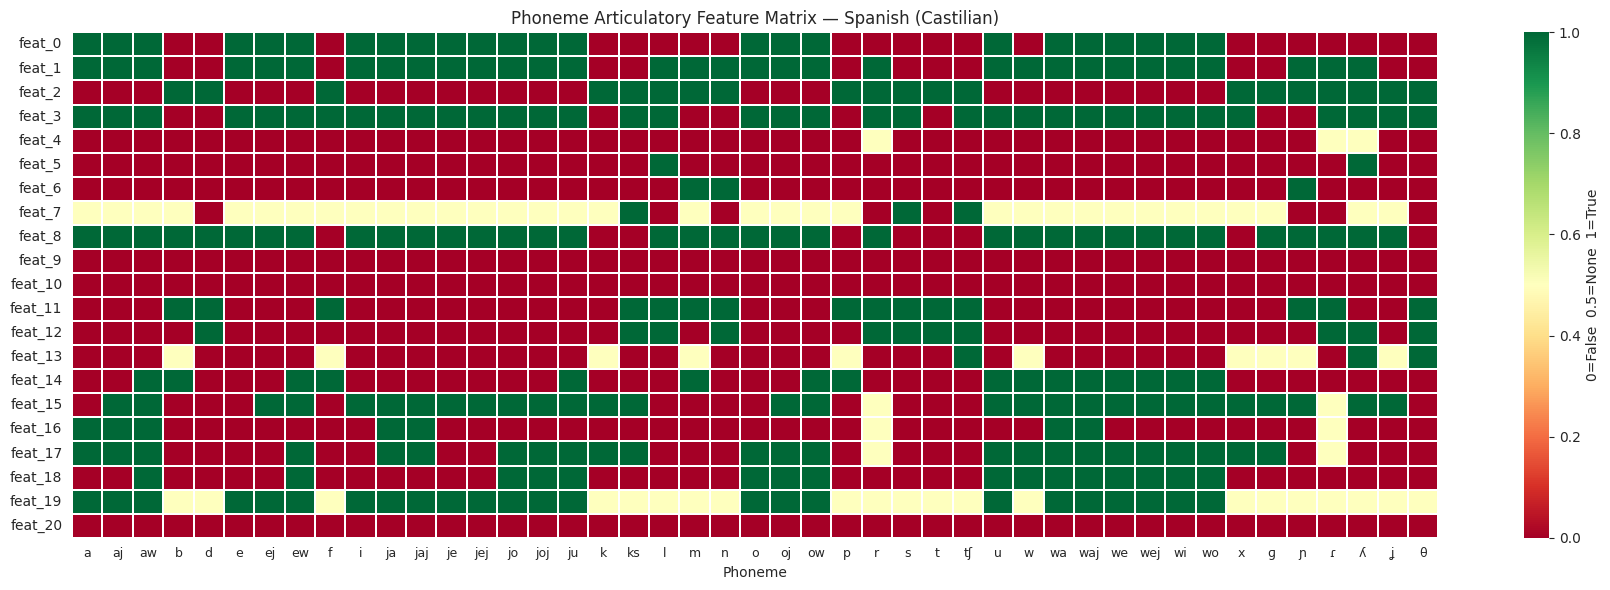

Saved: ./outputs/feat_heatmap_es.png


In [9]:
# ── Feature heatmap ───────────────────────────────────────────────────────────
# Shows which articulatory features each phoneme has set to True (1), False (0), or None (0.5)

fig, ax = plt.subplots(figsize=(max(10, len(phonemes) * 0.4), 6))
sns.heatmap(
    embed_mat.T,
    ax=ax,
    xticklabels=phonemes,
    yticklabels=[f"feat_{i}" for i in range(embed_mat.shape[1])],
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "0=False  0.5=None  1=True"},
)
ax.set_title(f"Phoneme Articulatory Feature Matrix — {orthography2ipa.get(LANG_CODE).name}")
ax.set_xlabel("Phoneme")
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
path = f"{OUTPUT_DIR}/feat_heatmap_{LANG_CODE}.png"
plt.savefig(path, dpi=130, bbox_inches="tight")
#log_artifact(path)
plt.show()
print(f"Saved: {path}")

/home/miro/PycharmProjects/wakeHuBert/.venv/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


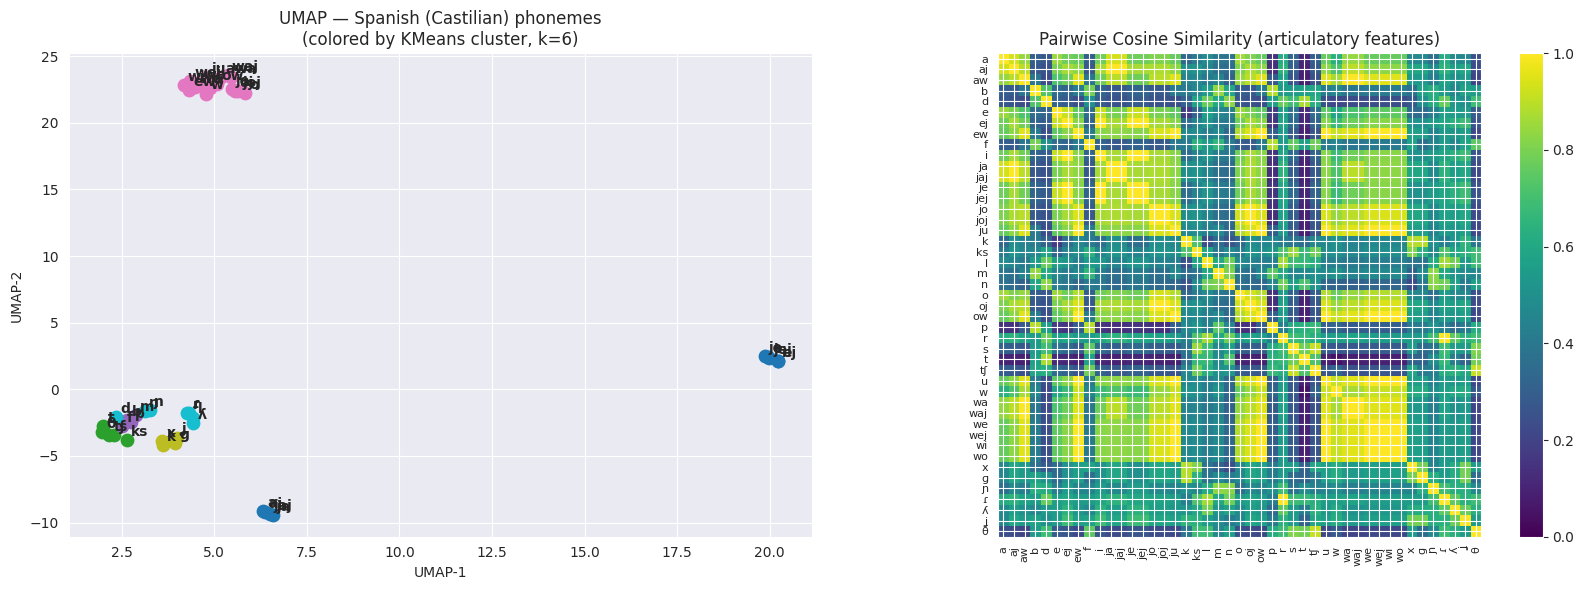


KMeans phoneme clusters:
  Cluster 0: ['a', 'aj', 'e', 'ej', 'i', 'ja', 'jaj', 'je', 'jej']
  Cluster 1: ['ks', 's', 't', 'tʃ', 'θ']
  Cluster 2: ['b', 'f', 'm', 'p']
  Cluster 3: ['aw', 'ew', 'jo', 'joj', 'ju', 'o', 'oj', 'ow', 'u', 'w', 'wa', 'waj', 'we', 'wej', 'wi', 'wo']
  Cluster 4: ['k', 'x', 'ɡ', 'ʝ']
  Cluster 5: ['d', 'l', 'n', 'r', 'ɲ', 'ɾ', 'ʎ']


In [11]:
# ── UMAP / PCA 2D projection ──────────────────────────────────────────────────
try:
    import umap
    coords = umap.UMAP(n_components=2, random_state=42,
                       n_neighbors=min(5, len(phonemes)-1)).fit_transform(embed_mat)
    proj_label = "UMAP"
except ImportError:
    from sklearn.decomposition import PCA
    coords = PCA(n_components=2).fit_transform(embed_mat)
    proj_label = "PCA"

# ── KMeans clustering ─────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
k = min(N_CLUSTERS, len(phonemes))
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(embed_mat)
labels = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: by cluster
palette = plt.cm.tab10(np.linspace(0, 1, k))
ax = axes[0]
for cl in range(k):
    mask = labels == cl
    ax.scatter(coords[mask, 0], coords[mask, 1], c=[palette[cl]], s=80, zorder=3)
for i, p in enumerate(phonemes):
    ax.annotate(p, (coords[i, 0], coords[i, 1]), xytext=(3, 3),
                textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_title(f"{proj_label} — {orthography2ipa.get(LANG_CODE).name} phonemes\n(colored by KMeans cluster, k={k})")
ax.set_xlabel(f"{proj_label}-1"); ax.set_ylabel(f"{proj_label}-2")

# Plot 2: pairwise cosine similarity matrix
sim_mat = cosine_similarity(embed_mat)
ax2 = axes[1]
im = ax2.imshow(sim_mat, cmap="viridis", vmin=0, vmax=1)
ax2.set_xticks(range(len(phonemes))); ax2.set_xticklabels(phonemes, fontsize=8, rotation=90)
ax2.set_yticks(range(len(phonemes))); ax2.set_yticklabels(phonemes, fontsize=8)
ax2.set_title("Pairwise Cosine Similarity (articulatory features)")
plt.colorbar(im, ax=ax2, fraction=0.04)

plt.tight_layout()
path = f"{OUTPUT_DIR}/phoneme_space_{LANG_CODE}.png"
plt.savefig(path, dpi=130, bbox_inches="tight")
#log_artifact(path)
plt.show()

# Print clusters
print("\nKMeans phoneme clusters:")
for cl in range(k):
    members = [phonemes[i] for i in range(len(phonemes)) if labels[i] == cl]
    print(f"  Cluster {cl}: {members}")

In [13]:
# ── Nearest-neighbour lookup ──────────────────────────────────────────────────

def nearest_phonemes(query: str, embeds: dict, k: int = 5) -> list[tuple[str, float]]:
    """Return the k most articulatorily similar phonemes to `query`."""
    if query not in embeds:
        raise KeyError(f"'{query}' not in embeddings")
    q = embeds[query].reshape(1, -1)
    phonemes_ = [p for p in embeds if p != query]
    vecs = np.stack([embeds[p] for p in phonemes_])
    sims = cosine_similarity(q, vecs)[0]
    order = np.argsort(sims)[::-1]
    return [(phonemes_[i], float(sims[i])) for i in order[:k]]

# Try a few interesting phonemes
spec = orthography2ipa.get(LANG_CODE)
probes = [p for p in ["b", "p", "s", "n", "a", "i"] if p in embeds]

print(f"\nNearest articulatory neighbours ({LANG_CODE}):")
for query in probes:
    nns = nearest_phonemes(query, embeds)
    nn_str = "  ".join(f"{p} ({s:.3f})" for p, s in nns)
    print(f"  /{query}/  →  {nn_str}")


Nearest articulatory neighbours (es):
  /b/  →  p (0.889)  m (0.839)  f (0.789)  d (0.723)  ɲ (0.630)
  /p/  →  b (0.889)  f (0.889)  m (0.745)  tʃ (0.671)  t (0.645)
  /s/  →  tʃ (0.917)  ks (0.851)  θ (0.810)  t (0.787)  f (0.751)
  /n/  →  d (0.825)  ɲ (0.824)  m (0.808)  ɾ (0.780)  r (0.780)
  /a/  →  ja (0.937)  jaj (0.937)  aj (0.937)  o (0.862)  e (0.851)
  /i/  →  jej (1.000)  je (1.000)  ej (1.000)  e (0.917)  joj (0.870)


/home/miro/PycharmProjects/wakeHuBert/.venv/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


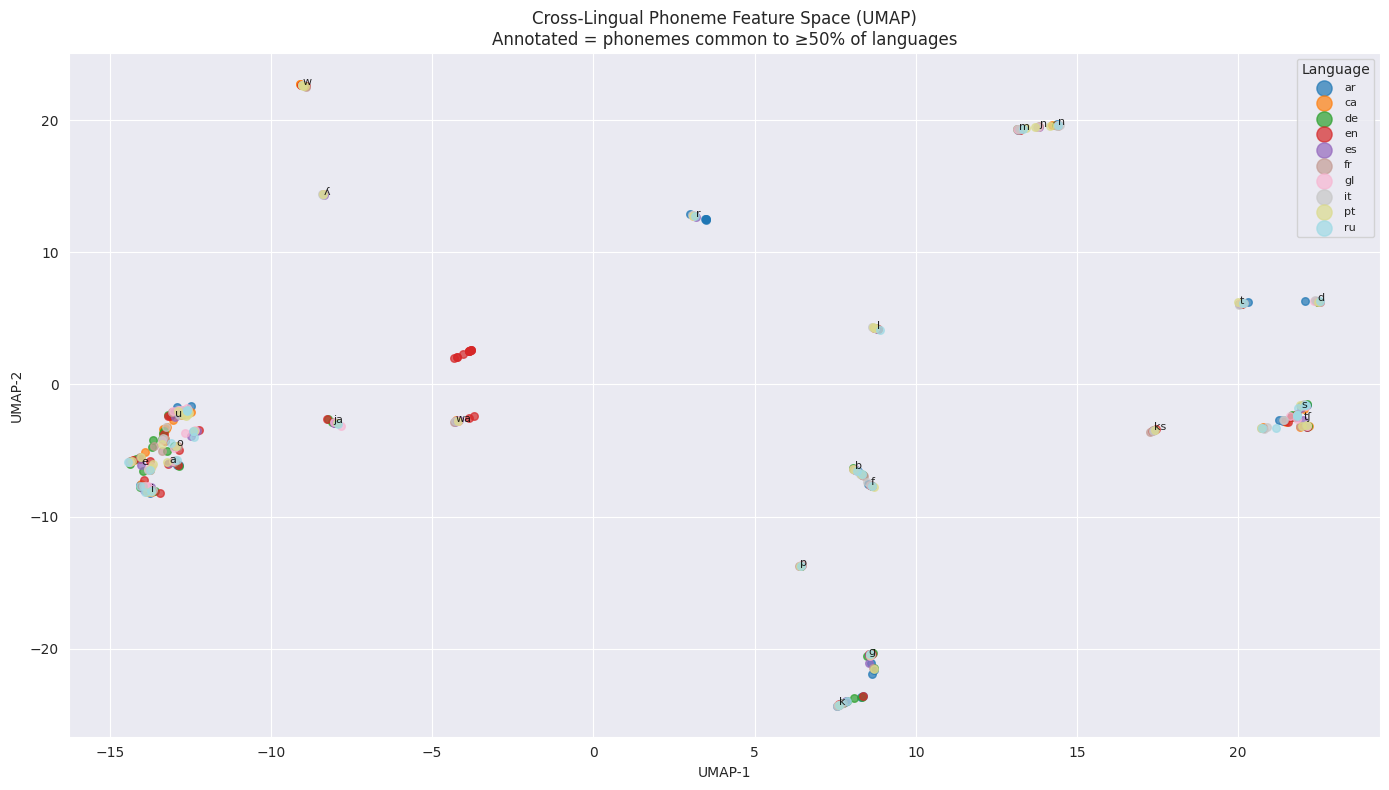

✅ Cross-lingual plot: 442 phoneme vectors from 10 languages


In [15]:
# ── Cross-lingual feature space ───────────────────────────────────────────────
# Overlay embeddings from multiple languages in the same 2D space

embed_lang_codes = [c.strip() for c in EMBED_LANGS.split(",") if c.strip()]

all_vecs, all_phones, all_langs = [], [], []
for code in embed_lang_codes:
    try:
        e = phoneme_embeddings(code)
        for p, v in e.items():
            all_vecs.append(v)
            all_phones.append(p)
            all_langs.append(code)
    except Exception as ex:
        print(f"⚠️  Skipping {code}: {ex}")

if len(all_vecs) < 3:
    print("⚠️  Not enough data for cross-lingual plot")
else:
    cross_mat = np.stack(all_vecs)
    try:
        import umap
        cross_coords = umap.UMAP(n_components=2, random_state=42,
                                  n_neighbors=min(10, len(cross_mat)-1)).fit_transform(cross_mat)
        cross_label = "UMAP"
    except ImportError:
        from sklearn.decomposition import PCA
        cross_coords = PCA(n_components=2).fit_transform(cross_mat)
        cross_label = "PCA"

    unique_langs = sorted(set(all_langs))
    pal = plt.cm.tab20(np.linspace(0, 1, len(unique_langs)))
    lang_color = {l: pal[i] for i, l in enumerate(unique_langs)}

    fig, ax = plt.subplots(figsize=(14, 8))
    for lang in unique_langs:
        mask = [i for i, l in enumerate(all_langs) if l == lang]
        ax.scatter(cross_coords[mask, 0], cross_coords[mask, 1],
                   c=[lang_color[lang]], label=lang, s=30, alpha=0.7)
    # Annotate points where the same IPA appears in multiple languages (cross-lingual anchors)
    from collections import Counter as C_
    ipa_counts = C_(all_phones)
    anchor_ipa = {p for p, cnt in ipa_counts.items() if cnt >= len(unique_langs) * 0.5}
    for i, (p, lang) in enumerate(zip(all_phones, all_langs)):
        if p in anchor_ipa and lang == embed_lang_codes[0]:
            ax.annotate(p, (cross_coords[i, 0], cross_coords[i, 1]),
                        fontsize=8, color="black", alpha=0.85)
    ax.legend(fontsize=8, markerscale=2, title="Language", loc="best")
    ax.set_title(f"Cross-Lingual Phoneme Feature Space ({cross_label})\nAnnotated = phonemes common to ≥50% of languages")
    ax.set_xlabel(f"{cross_label}-1"); ax.set_ylabel(f"{cross_label}-2")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/crosslingual_feat_space.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    #log_artifact(path)
    plt.show()
    print(f"✅ Cross-lingual plot: {len(all_vecs)} phoneme vectors from {len(unique_langs)} languages")

---
## Part 2 — `build_ngram_lm()` + `perplexity()`: Phonotactic Language Model

In [18]:
# ── Train the n-gram LM ───────────────────────────────────────────────────────
print(f"Training {NGRAM_N}-gram LM on {len(train_words)} words ({LANG_CODE})...")
lm = build_ngram_lm(train_words, LANG_CODE, n=NGRAM_N)

n_contexts = len(lm)
n_entries  = sum(len(v) for v in lm.values())
print(f"✅ LM built | contexts: {n_contexts:,} | total n-gram entries: {n_entries:,}")
#log_metric("lm_n_contexts", n_contexts)
#log_metric("lm_n_entries", n_entries)

# ── Evaluate on held-out test words ───────────────────────────────────────────
train_ppl = perplexity(lm, train_words[:200], LANG_CODE, n=NGRAM_N)
test_ppl  = perplexity(lm, test_words,        LANG_CODE, n=NGRAM_N)
print(f"\n  Train PPL (sample): {train_ppl:.2f}")
print(f"  Test  PPL:          {test_ppl:.2f}")
#log_metric("train_ppl", train_ppl)
#log_metric("test_ppl",  test_ppl)

Training 3-gram LM on 5000 words (es)...
✅ LM built | contexts: 611 | total n-gram entries: 9,288

  Train PPL (sample): 15.58
  Test  PPL:          18.72


  n=1: test_ppl=20.33  contexts=1
  n=2: test_ppl=19.10  contexts=27
  n=3: test_ppl=18.72  contexts=611
  n=4: test_ppl=5.72  contexts=8,766
  n=5: test_ppl=1.42  contexts=19,034


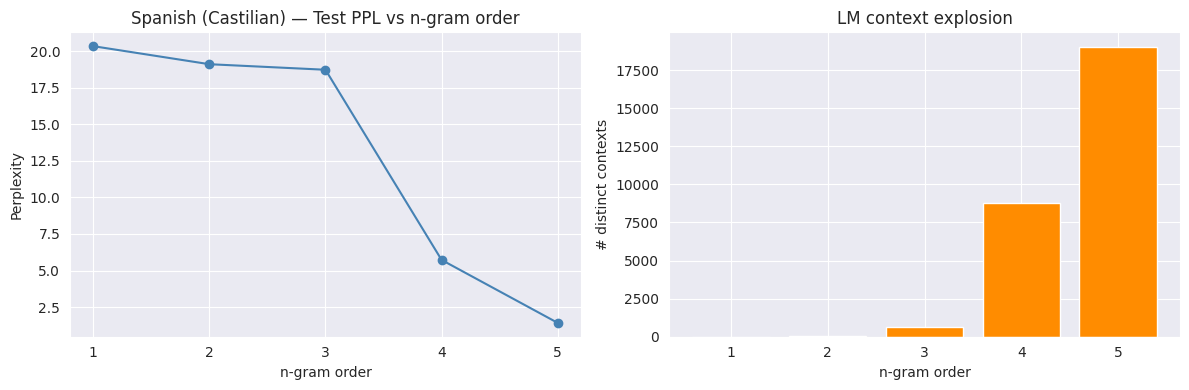

In [20]:
# ── N-gram order comparison ────────────────────────────────────────────────────
# How much does perplexity change as n increases?

ngram_results = []
for n in range(1, 6):
    lm_n = build_ngram_lm(train_words, LANG_CODE, n=n)
    ppl_n = perplexity(lm_n, test_words, LANG_CODE, n=n)
    ngram_results.append({"n": n, "contexts": len(lm_n), "test_ppl": ppl_n})
    print(f"  n={n}: test_ppl={ppl_n:.2f}  contexts={len(lm_n):,}")
    #log_metric(f"ppl_n{n}", ppl_n)

ng_df = pd.DataFrame(ngram_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ng_df["n"], ng_df["test_ppl"], marker="o", color="steelblue")
axes[0].set_xlabel("n-gram order"); axes[0].set_ylabel("Perplexity")
axes[0].set_title(f"{orthography2ipa.get(LANG_CODE).name} — Test PPL vs n-gram order")
axes[0].set_xticks(ng_df["n"])

axes[1].bar(ng_df["n"].astype(str), ng_df["contexts"], color="darkorange")
axes[1].set_xlabel("n-gram order"); axes[1].set_ylabel("# distinct contexts")
axes[1].set_title("LM context explosion")

plt.tight_layout()
path = f"{OUTPUT_DIR}/ngram_sweep_{LANG_CODE}.png"
plt.savefig(path, dpi=120, bbox_inches="tight")
#log_artifact(path)
plt.show()


Lowest-PPL words (most phonotactically predictable):
    word        ipa      ppl
     lle         ʎe 2.828427
    rryú        rʝu 3.766383
    wxxó     wkskso 7.272157
    iorx      joɾks 7.595555
     fxu       fksu 7.989987
     flx       flks 8.525079
    fhcí        fki 8.793037
     dqo        dko 9.102876
sksxrxye sksksɾksʝe 9.418257
    cçwç       ksws 9.728017

Highest-PPL words (most phonotactically surprising):
     word       ipa       ppl
ñédwelduv ɲedweldub 30.353484
  ctjstoy   ktxstoj 30.369379
    ánuzf     anuθf 31.341305
  oñoaníj   oɲoanix 31.577754
  lçnfyuu   lsnfʝuu 31.592689
vuíóewnkñ buioewnkɲ 32.047738
    oúiim     ouiim 32.615604
      oúr       ouɾ 32.708067
  áyüúümi   aʝwuwmi 33.682004
ümilowdóh  wmilowdo 36.058239


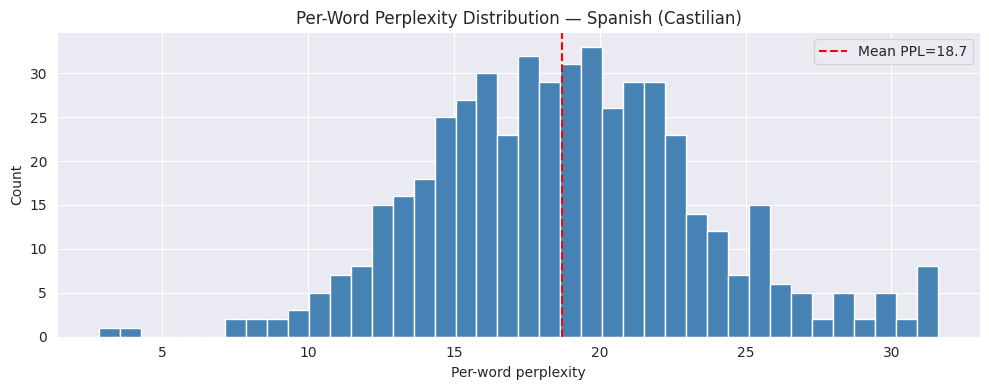

In [22]:
# ── Per-word perplexity distribution ─────────────────────────────────────────
# Which words does the model find most/least surprising?

spec_main = orthography2ipa.get(LANG_CODE)
tok_main  = PhonetokTokenizer(spec_main)

word_ppls = []
for word in test_words:
    ppl_w = perplexity(lm, [word], LANG_CODE, n=NGRAM_N)
    if ppl_w != float('inf'):
        word_ppls.append({"word": word, "ppl": ppl_w,
                          "len": len(word),
                          "ipa": tok_main.ipa_beam(word, beam_width=1)[0].ipa
                                 if tok_main.ipa_beam(word, beam_width=1) else ""})

wp_df = pd.DataFrame(word_ppls).sort_values("ppl")

print("\nLowest-PPL words (most phonotactically predictable):")
print(wp_df.head(10)[["word", "ipa", "ppl"]].to_string(index=False))
print("\nHighest-PPL words (most phonotactically surprising):")
print(wp_df.tail(10)[["word", "ipa", "ppl"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wp_df["ppl"].clip(upper=wp_df["ppl"].quantile(0.99)), bins=40,
        color="steelblue", edgecolor="white")
ax.axvline(test_ppl, color="red", linestyle="--", label=f"Mean PPL={test_ppl:.1f}")
ax.set_xlabel("Per-word perplexity"); ax.set_ylabel("Count")
ax.set_title(f"Per-Word Perplexity Distribution — {spec_main.name}")
ax.legend()
plt.tight_layout()
path = f"{OUTPUT_DIR}/word_ppl_dist_{LANG_CODE}.png"
plt.savefig(path, dpi=120, bbox_inches="tight")
#log_artifact(path)
plt.show()


Top-15 highest-entropy contexts (most ambiguous):
  Context                               Entropy   Count  Top continuations 
  --------------------------------------------------------------------------------
  ('<s>', 't')                            4.405     160  /l/, /ɲ/, /n/, /m/
  ('s', 'a')                              4.377     132  /ɲ/, /l/, /b/, /a/
  ('<s>', 'e')                            4.363     315  /ɲ/, /t/, /a/, /s/
  ('<s>', 'i')                            4.349     286  /ɲ/, /b/, /o/, /u/
  ('<s>', 'ɡ')                            4.346     156  /f/, /a/, /k/, /i/
  ('<s>', 'o')                            4.343     316  /θ/, /w/, /m/, /t/
  ('<s>', 'w')                            4.320     285  /s/, /ɡ/, /θ/, /b/
  ('s', 'e')                              4.297     142  /e/, /b/, /d/, /θ/
  ('<s>', 'n')                            4.294     155  /w/, /θ/, /d/, /ɾ/
  ('<s>', 'u')                            4.290     288  /ɾ/, /w/, /f/, /k/
  ('<s>', 'a')                

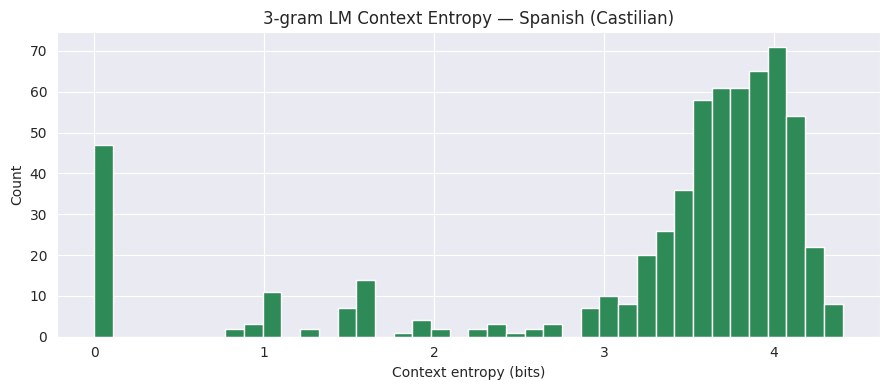

In [25]:
# ── LM context entropy — what does the model know? ────────────────────────────
# For each context in the LM, compute entropy over next-phone distribution.
# High entropy = many equally likely continuations (ambiguous context).
# Low entropy  = model is confident about what comes next.

from collections import Counter

def context_entropy(dist: Counter) -> float:
    total = sum(dist.values())
    if total == 0: return 0.0
    return -sum((c/total) * math.log2(c/total) for c in dist.values() if c > 0)

ctx_entropies = [(ctx, context_entropy(dist), sum(dist.values()))
                 for ctx, dist in lm.items()]
ctx_entropies.sort(key=lambda x: -x[1])

print(f"\nTop-15 highest-entropy contexts (most ambiguous):")
print(f"  {'Context':35s}  {'Entropy':>8}  {'Count':>6}  {'Top continuations'} ")
print("  " + "-" * 80)
for ctx, ent, cnt in ctx_entropies[:15]:
    top_cont = ", ".join(f"/{p}/" for p in list(lm[ctx].keys())[:4])
    print(f"  {str(ctx):35s}  {ent:8.3f}  {cnt:6d}  {top_cont}")

print(f"\nTop-15 lowest-entropy contexts (most deterministic):")
print(f"  {'Context':35s}  {'Entropy':>8}  {'Count':>6}  {'Continuation'}")
print("  " + "-" * 80)
certain = [x for x in ctx_entropies if x[2] >= 3]  # need enough observations
for ctx, ent, cnt in sorted(certain, key=lambda x: x[1])[:15]:
    cont = list(lm[ctx].keys())[0]
    print(f"  {str(ctx):35s}  {ent:8.3f}  {cnt:6d}  /{cont}/")

# Plot entropy distribution
entropies = [e for _, e, _ in ctx_entropies]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(entropies, bins=40, color="seagreen", edgecolor="white")
ax.set_xlabel("Context entropy (bits)"); ax.set_ylabel("Count")
ax.set_title(f"{NGRAM_N}-gram LM Context Entropy — {spec_main.name}")
plt.tight_layout()
path = f"{OUTPUT_DIR}/context_entropy_{LANG_CODE}.png"
plt.savefig(path, dpi=120, bbox_inches="tight")
#log_artifact(path)
plt.show()
#log_metric("mean_context_entropy", float(np.mean(entropies)))

---
## Part 3 — Cross-Lingual Perplexity

In [26]:
# ── Train LMs for all comparison languages ────────────────────────────────────
compare_codes = [c.strip() for c in COMPARE_LANGS.split(",") if c.strip()]

# For each language, build a word list and LM
lang_lms   = {LANG_CODE: lm}          # already built above
lang_words = {LANG_CODE: test_words}   # test words for the primary lang

for code in compare_codes:
    try:
        w = make_word_list(code, N_TRAIN_WORDS, seed=99)
        lang_lms[code]   = build_ngram_lm(w[:N_TRAIN_WORDS], code, n=NGRAM_N)
        lang_words[code] = w[N_TRAIN_WORDS:N_TRAIN_WORDS + N_TEST_WORDS]
        print(f"  ✅ {code}: LM built ({len(w[:N_TRAIN_WORDS])} train words)")
    except Exception as e:
        print(f"  ⚠️  {code}: {e}")

print(f"\n✅ LMs ready for: {list(lang_lms.keys())}")

  ✅ pt: LM built (5000 train words)
  ✅ it: LM built (5000 train words)
  ✅ fr: LM built (5000 train words)
  ✅ ca: LM built (5000 train words)
  ✅ gl: LM built (5000 train words)

✅ LMs ready for: ['es', 'pt', 'it', 'fr', 'ca', 'gl']



Cross-lingual perplexity matrix (row=LM lang, col=word lang):
      es  pt  it  fr  ca  gl
es  18.7 NaN NaN NaN NaN NaN
pt  20.9 NaN NaN NaN NaN NaN
it  16.7 NaN NaN NaN NaN NaN
fr  18.4 NaN NaN NaN NaN NaN
ca  19.3 NaN NaN NaN NaN NaN
gl  19.5 NaN NaN NaN NaN NaN


NameError: name 'log_artifact' is not defined

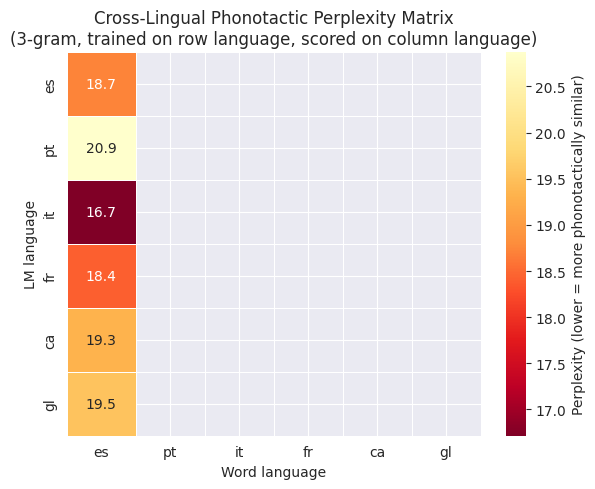

In [27]:
# ── Cross-perplexity matrix ───────────────────────────────────────────────────
# Row = LM trained on language A
# Col = word list from language B
# Cell = perplexity of A's LM on B's words
# Diagonal = same-language PPL (baseline)
# Off-diagonal: lower means A's phonotactics transfer to B

all_codes = list(lang_lms.keys())
ppl_matrix = np.full((len(all_codes), len(all_codes)), float('nan'))

for i, lm_lang in enumerate(all_codes):
    for j, word_lang in enumerate(all_codes):
        if word_lang not in lang_words or not lang_words[word_lang]:
            continue
        try:
            # Score word_lang's words using lm_lang's model
            # Words are transcribed via word_lang's tokenizer, then scored by lm_lang's LM
            ppl_ij = perplexity(lang_lms[lm_lang], lang_words[word_lang], lm_lang, n=NGRAM_N)
            ppl_matrix[i, j] = ppl_ij if ppl_ij != float('inf') else np.nan
        except Exception:
            pass

ppl_df = pd.DataFrame(ppl_matrix, index=all_codes, columns=all_codes)
print("\nCross-lingual perplexity matrix (row=LM lang, col=word lang):")
print(ppl_df.round(1).to_string())

fig, ax = plt.subplots(figsize=(max(6, len(all_codes)), max(5, len(all_codes) * 0.8)))
mask = np.isnan(ppl_matrix)
sns.heatmap(
    ppl_df, ax=ax,
    annot=True, fmt=".1f",
    cmap="YlOrRd_r",       # reversed: green=low PPL=similar phonotactics
    mask=mask,
    linewidths=0.5,
    cbar_kws={"label": "Perplexity (lower = more phonotactically similar)"},
)
ax.set_title(f"Cross-Lingual Phonotactic Perplexity Matrix\n({NGRAM_N}-gram, trained on row language, scored on column language)")
ax.set_xlabel("Word language"); ax.set_ylabel("LM language")
plt.tight_layout()
path = f"{OUTPUT_DIR}/crosslingual_ppl_matrix.png"
plt.savefig(path, dpi=130, bbox_inches="tight")
log_artifact(path)
plt.show()

# Log diagonal (same-language PPL) and best cross-lingual match
for i, code in enumerate(all_codes):
    if not np.isnan(ppl_matrix[i, i]):
        log_metric(f"self_ppl_{code}", ppl_matrix[i, i])
    off_diag = [(ppl_matrix[i, j], all_codes[j]) for j in range(len(all_codes)) if i != j and not np.isnan(ppl_matrix[i, j])]
    if off_diag:
        best_ppl, best_lang = min(off_diag)
        print(f"  {code}: closest language by LM = {best_lang} (PPL={best_ppl:.1f}, self={ppl_matrix[i,i]:.1f})")

In [ ]:
# ── Phonotactic distance dendogram ────────────────────────────────────────────
# Convert the PPL matrix into a symmetric distance, then hierarchically cluster

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Symmetrize: dist(A, B) = (ppl(A→B) + ppl(B→A)) / 2
sym = (ppl_matrix + ppl_matrix.T) / 2
sym = np.nan_to_num(sym, nan=np.nanmax(sym) * 1.5)  # fill NaN with large value
np.fill_diagonal(sym, 0.0)

# Normalize to [0, 1] for distance
max_val = sym.max()
dist_mat = sym / (max_val + 1e-8)

# Only cluster languages with enough data (no all-NaN rows)
valid_mask = ~np.all(np.isnan(ppl_matrix), axis=1)
valid_codes = [all_codes[i] for i in range(len(all_codes)) if valid_mask[i]]
valid_dist  = dist_mat[np.ix_(valid_mask, valid_mask)]

if len(valid_codes) >= 3:
    condensed = squareform(valid_dist, checks=False)
    Z = linkage(condensed, method="average")

    fig, ax = plt.subplots(figsize=(max(8, len(valid_codes) * 0.8), 5))
    dendrogram(Z, labels=valid_codes, ax=ax, leaf_rotation=45)
    ax.set_title(f"Language Phonotactic Similarity (dendogram)\n"
                 f"Based on {NGRAM_N}-gram cross-perplexity distance")
    ax.set_ylabel("Distance")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/phonotactic_dendogram.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    log_artifact(path)
    plt.show()
    print("✅ Dendogram saved")
else:
    print("⚠️  Need at least 3 languages with data for dendogram")

---
## Part 4 — Combining Both: Feature Similarity vs LM Perplexity

In [ ]:
# ── Do phoneme feature similarity and phonotactic PPL agree? ──────────────────
# For each pair of languages we now have:
#   - feature_sim: avg cosine sim of shared phoneme feature vectors (from phoneme_embeddings)
#   - cross_ppl:   cross-lingual perplexity (from build_ngram_lm + perplexity)
# Hypothesis: high feature similarity should correlate with low cross-PPL.

feat_sims, cross_ppls, pair_labels = [], [], []

for i, code_a in enumerate(all_codes):
    for j, code_b in enumerate(all_codes):
        if i >= j: continue
        if np.isnan(ppl_matrix[i, j]) or np.isnan(ppl_matrix[j, i]): continue
        try:
            emb_a = phoneme_embeddings(code_a)
            emb_b = phoneme_embeddings(code_b)
        except Exception:
            continue
        shared = set(emb_a.keys()) & set(emb_b.keys())
        if len(shared) < 3:
            continue
        vecs_a = np.stack([emb_a[p] for p in shared])
        vecs_b = np.stack([emb_b[p] for p in shared])
        avg_sim = float(np.mean([
            cosine_similarity(vecs_a[k].reshape(1,-1), vecs_b[k].reshape(1,-1))[0,0]
            for k in range(len(shared))
        ]))
        avg_ppl = (ppl_matrix[i, j] + ppl_matrix[j, i]) / 2
        feat_sims.append(avg_sim)
        cross_ppls.append(avg_ppl)
        pair_labels.append(f"{code_a}–{code_b}")

if len(feat_sims) >= 3:
    from scipy import stats
    r, pval = stats.pearsonr(feat_sims, cross_ppls)
    print(f"Pearson r (feat_sim vs cross_ppl): {r:.3f}  (p={pval:.4f})")
    log_metric("feat_ppl_pearson_r", r)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(feat_sims, cross_ppls, s=60, color="steelblue", zorder=3)
    for x, y, label in zip(feat_sims, cross_ppls, pair_labels):
        ax.annotate(label, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=7)
    # Regression line
    m, b = np.polyfit(feat_sims, cross_ppls, 1)
    xs = np.linspace(min(feat_sims), max(feat_sims), 100)
    ax.plot(xs, m*xs + b, color="tomato", linestyle="--", label=f"r={r:.2f}")
    ax.set_xlabel("Avg feature cosine similarity (shared phonemes)")
    ax.set_ylabel("Avg cross-lingual perplexity")
    ax.set_title("Feature Similarity vs Phonotactic Perplexity\nHypothesis: similar phoneme inventories → lower cross-PPL")
    ax.legend()
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/feat_sim_vs_ppl.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    log_artifact(path)
    plt.show()
else:
    print("⚠️  Not enough language pairs for correlation plot — add more COMPARE_LANGS")

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for code in all_codes:
    idx = all_codes.index(code)
    try:
        e = phoneme_embeddings(code)
        n_ph = len(e)
    except Exception:
        n_ph = 0
    self_ppl = ppl_matrix[idx, idx] if not np.isnan(ppl_matrix[idx, idx]) else float('nan')
    n_ctx    = len(lang_lms[code]) if code in lang_lms else 0
    summary_rows.append({
        "lang": code,
        "name": orthography2ipa.get(code).name,
        "n_phonemes": n_ph,
        "lm_contexts": n_ctx,
        "self_ppl": round(self_ppl, 2),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n📋 Summary:")
print(summary_df.to_string(index=False))

summary_path = f"{OUTPUT_DIR}/summary.csv"
summary_df.to_csv(summary_path, index=False)
log_artifact(summary_path)

memory_checkpoint("end of notebook")

if MLFLOW_AVAILABLE:
    mlflow.end_run()
    print("✅ MLflow run ended")